In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import sys
from pathlib import Path

# Add src to path
sys.path.insert(0, str(Path.cwd().parent / 'src'))

from config import PROCESSED_DATA_DIR

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline

## 1. Load Final Dataset

In [3]:
# TODO: Load dashboard_data.parquet
# %%
# Path to final dataset
dashboard_data_path = PROCESSED_DATA_DIR / "dashboard_data.parquet"

# Load dataset
df = pd.read_parquet(dashboard_data_path)
print("Dashboard dataset shape:", df.shape)
df.head()


Dashboard dataset shape: (200000, 37)


,crash_date,crash_time,on_street_name,off_street_name,number_of_persons_injured,number_of_persons_killed,number_of_pedestrians_injured,number_of_pedestrians_killed,number_of_cyclist_injured,number_of_cyclist_killed,number_of_motorist_injured,number_of_motorist_killed,contributing_factor_vehicle_1,contributing_factor_vehicle_2,collision_id,vehicle_type_code1,vehicle_type_code2,borough,zip_code,latitude,longitude,location,crash_year,crash_month,crash_day,crash_day_of_week,is_weekend,crash_hour,lat_bin,lon_bin,total_injured,total_killed,severity_score,num_vehicle_types,has_truck,has_bus,has_bicycle
0,2025-09-30,09:30:00,None,None,1,0,0,0,0,0,1,0,Turning Improperly,Unspecified,4847219,STATION WAGON/SPORT UTILITY VEHICLE,TRACTOR TRUCK DIESEL,BRONX,10460,40.832653,-73.886110,"{'human_address': '{""address"": """", ""city"": """",...",2025,9,30,1,0,NaN,5,6,2,0,2,2,1,0,0
1,2018-09-19,17:20:00,GRAND CENTRAL PKWY,None,0,0,0,0,0,0,0,0,Driver Inexperience,Unspecified,3984888,STATION WAGON/SPORT UTILITY VEHICLE,SEDAN,NONE,None,40.715958,-73.812750,"{'human_address': None, 'latitude': '40.715958...",2018,9,19,2,0,NaN,3,7,0,0,0,2,0,0,0
2,2018-07-23,13:00:00,JUNCTION BOULEVARD,40 ROAD,0,0,0,0,0,0,0,0,Following Too Closely,Unspecified,3947176,BOX TRUCK,SEDAN,NONE,None,40.748760,-73.869200,"{'human_address': None, 'latitude': '40.74876'...",2018,7,23,0,0,NaN,3,6,0,0,0,2,1,0,0
3,2016-08-01,08:00:00,TILLOTSON AVENUE,None,0,0,0,0,0,0,0,0,Unspecified,None,3498631,STATION WAGON/SPORT UTILITY VEHICLE,NONE,NONE,None,40.878155,-73.840050,"{'human_address': None, 'latitude': '40.878155...",2016,8,1,0,0,NaN,6,7,0,0,0,2,0,0,0
4,2012-07-14,20:55:00,EAST 26 STREET,EMMONS AVENUE,0,0,0,0,0,0,0,0,Unspecified,Unspecified,116377,PASSENGER VEHICLE,PASSENGER VEHICLE,BROOKLYN,11235,40.583699,-73.942584,"{'human_address': None, 'latitude': '40.583699...",2012,7,14,5,1,NaN,1,5,0,0,0,2,0,0,0


## 2. Temporal Analysis

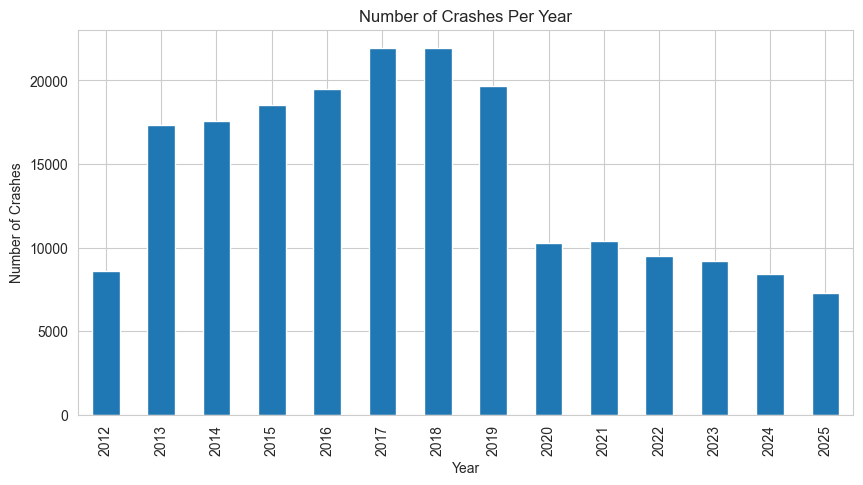

In [4]:
# TODO: Time series plots
# Seasonal patterns
# Hour/day distributions
# %%
# Example: crashes per year
plt.figure(figsize=(10,5))
df['crash_year'].value_counts().sort_index().plot(kind='bar')
plt.title("Number of Crashes Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Crashes")
plt.show()

# Example: crashes by hour of day
fig = px.histogram(df, x='crash_hour', nbins=24, title='Crashes by Hour')
fig.show()


## 3. Spatial Analysis

In [6]:
# TODO: Geographic heatmaps
# Borough comparisons
# Hot spots identification

# 1) Heatmap / bar chart by borough
borough_counts = df['borough'].value_counts()
fig = px.bar(
    borough_counts,
    x=borough_counts.index,
    y=borough_counts.values,
    title="Crashes by Borough",
    labels={'x': 'Borough', 'y': 'Number of Crashes'}
)
fig.show()

# 2) Map visualization (if lat/lon available)

# Keep only rows with valid coordinates
map_df = df.dropna(subset=["latitude", "longitude"])

fig = px.scatter_mapbox(
    map_df,
    lat="latitude",
    lon="longitude",
    color="severity_score",
    size="total_injured",   # <-- was total_injuries
    size_max=15,
    zoom=10,
    mapbox_style="carto-positron",
    title="Crash Locations with Severity"
)
fig.show()


/var/folders/pg/6w5xds6d0zxdjdshsxthjxbm0000gn/T/ipykernel_2646/1061115414.py:21: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



## 4. Severity Analysis

In [10]:
# TODO: Injury/fatality analysis
# Contributing factors
# Vehicle type analysis

# 1) Injury vs Fatalities scatter plot
fig = px.scatter(
    df,
    x='total_injured',        # <-- corrected
    y='total_killed',         # <-- corrected
    color='borough',
    size='total_injured',     # <-- corrected
    title="Injuries vs Fatalities by Borough"
)
fig.show()

# 2) Top 10 contributing factors
factor_counts = df['contributing_factor_vehicle_1'].value_counts().nlargest(10)

fig = px.bar(
    factor_counts,
    x=factor_counts.index,
    y=factor_counts.values,
    title="Top 10 Contributing Factors"
)
fig.show()


## 5. Key Insights and Dashboard Recommendations

In [12]:
# Save filtered data for dashboard
df.to_parquet(PROCESSED_DATA_DIR / "dashboard_filtered.parquet", index=False)

# Borough options
borough_options = df['borough'].dropna().unique().tolist()

# Year options
year_options = sorted(df['crash_year'].dropna().unique().tolist())

# Vehicle options: combine type_code1 and type_code2
vehicle_cols = [col for col in ['vehicle_type_code1', 'vehicle_type_code2'] if col in df.columns]

if vehicle_cols:
    vehicle_series = pd.concat([df[col].dropna() for col in vehicle_cols])
    vehicle_options = sorted(vehicle_series.unique().tolist())
else:
    vehicle_options = []

print("Borough options:", borough_options)
print("Year options:", year_options[:10], "...")
print("Vehicle options:", vehicle_options[:10], "...")


Borough options: ['BRONX', 'NONE', 'BROOKLYN', 'QUEENS', 'MANHATTAN', 'STATEN ISLAND']
Year options: [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021] ...
Vehicle options: ['0', '000', '00000', '18 WEELER', '2 DR', '2 DR SEDAN', '2TON', '2YDSWHEELL', '3 WHEEL SC', '3 WHEEL VE'] ...


**TODO: Document:**
- Key findings from analysis
- Most impactful visualizations for dashboard
- Recommended filters and interactions
- Story to tell through the dashboard